In [1]:
from collections import deque

def bfs(graph, start_node):
    visited = set()
    queue = deque([start_node])
    visited.add(start_node)

    while queue:
        node = queue.popleft()
        print(node, end=" ")

        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['F'],
    'F': []
}

bfs(graph, 'A')

A B C D E F 

Q: Implement Breadth-First Search (BFS) traversal for the given graph starting from node 'A'.

BFS Traversal (List): ['A', 'B', 'C', 'D', 'E', 'F']
BFS Traversal (Path): A -> B -> C -> D -> E -> F

   Traversal
0         A
1         B
2         C
3         D
4         E
5         F


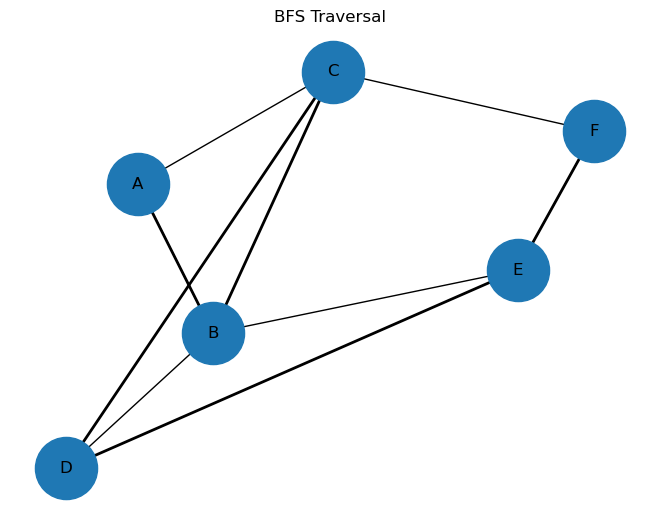

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

# Question
print("Q: Implement Breadth-First Search (BFS) traversal for the given graph starting from node 'A'.")

# Graph
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [], 'E': ['F'], 'F': []
}

# BFS
def bfs(g, start):
    visited, queue = [], deque([start])
    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            queue.extend(g[node])
    return visited

# Run BFS
result = bfs(graph, 'A')

# Arrow format
arrow_path = " -> ".join(result)

print("\nBFS Traversal (List):", result)
print("BFS Traversal (Path):", arrow_path)

# DataFrame
print("\n", pd.DataFrame(result, columns=["Traversal"]))

# Visualization
G = nx.Graph([(u, v) for u in graph for v in graph[u]])
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000)
nx.draw_networkx_edges(G, pos,
    edgelist=[(result[i], result[i+1]) for i in range(len(result)-1)],
    width=2)

plt.title("BFS Traversal")
plt.show()

 Implement Best-First Search traversal for the given graph starting from node 'A'.

Best-First Search Traversal (List): ['A', 'C', 'F', 'B', 'E', 'D']
Best-First Search Traversal (Path): A -> C -> F -> B -> E -> D

   Traversal
0         A
1         C
2         F
3         B
4         E
5         D


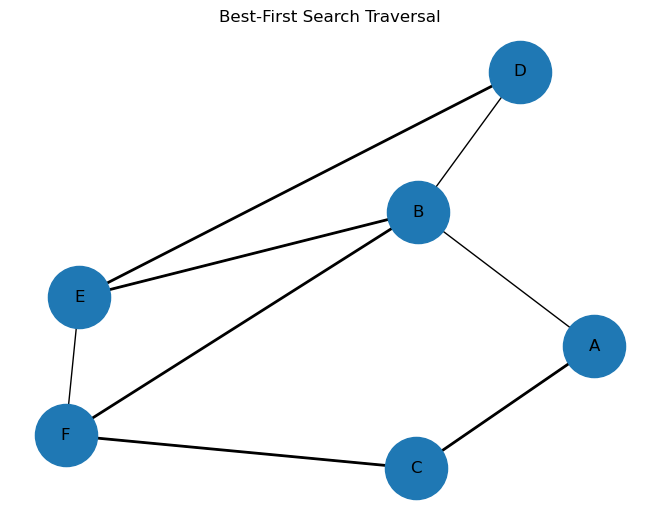

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import heapq


print(" Implement Best-First Search traversal for the given graph starting from node 'A'.")


graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 1)],
    'D': [],
    'E': [('F', 1)],
    'F': []
}


heuristic = {
    'A': 6,
    'B': 4,
    'C': 2,
    'D': 3,
    'E': 1,
    'F': 0
}

def best_first_search(graph, start):
    visited = []
    priority_queue = []

    heapq.heappush(priority_queue, (heuristic[start], start))

    while priority_queue:
        h, node = heapq.heappop(priority_queue)

        if node not in visited:
            visited.append(node)

            for neighbor, cost in graph[node]:
                if neighbor not in visited:
                    heapq.heappush(priority_queue,
                                   (heuristic[neighbor], neighbor))

    return visited

result = best_first_search(graph, 'A')

arrow_path = " -> ".join(result)

print("\nBest-First Search Traversal (List):", result)
print("Best-First Search Traversal (Path):", arrow_path)

print("\n", pd.DataFrame(result, columns=["Traversal"]))

G = nx.Graph([(u, v) for u in graph for v, c in graph[u]])
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000)

nx.draw_networkx_edges(
    G, pos,
    edgelist=[(result[i], result[i+1])
              for i in range(len(result)-1)],
    width=2
)

plt.title("Best-First Search Traversal")
plt.show()

Implement A* Search traversal for the given graph starting from node 'A'.

A* Search Traversal (List): ['A', 'B', 'C', 'F', 'D', 'E']
A* Search Traversal (Path): A -> B -> C -> F -> D -> E

   Traversal
0         A
1         B
2         C
3         F
4         D
5         E


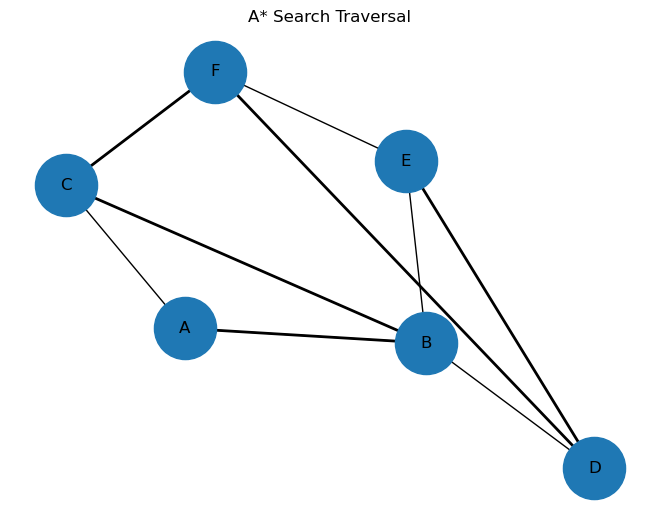

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import heapq

print("Implement A* Search traversal for the given graph starting from node 'A'.")

# Graph with costs
graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 1)],
    'D': [],
    'E': [('F', 1)],
    'F': []
}

# Heuristic values
heuristic = {
    'A': 6,
    'B': 4,
    'C': 2,
    'D': 3,
    'E': 1,
    'F': 0
}

# A* Search Function
def a_star_search(graph, start):
    visited = []
    priority_queue = []

    # g(n) cost dictionary
    g_cost = {node: float('inf') for node in graph}
    g_cost[start] = 0

    # Push start node
    heapq.heappush(priority_queue,
                   (heuristic[start], start))

    while priority_queue:
        f, node = heapq.heappop(priority_queue)

        if node not in visited:
            visited.append(node)

            for neighbor, cost in graph[node]:

                new_cost = g_cost[node] + cost

                if new_cost < g_cost[neighbor]:
                    g_cost[neighbor] = new_cost

                    f_cost = new_cost + heuristic[neighbor]

                    heapq.heappush(
                        priority_queue,
                        (f_cost, neighbor)
                    )

    return visited

# Run A* Search
result = a_star_search(graph, 'A')

# Arrow format
arrow_path = " -> ".join(result)

print("\nA* Search Traversal (List):", result)
print("A* Search Traversal (Path):", arrow_path)

# DataFrame
print("\n", pd.DataFrame(result, columns=["Traversal"]))

# Visualization
G = nx.Graph([(u, v) for u in graph for v, c in graph[u]])
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000)

nx.draw_networkx_edges(
    G, pos,
    edgelist=[(result[i], result[i+1])
              for i in range(len(result)-1)],
    width=2
)

plt.title("A* Search Traversal")
plt.show()

In [2]:
def dfs(graph, start_node, visited=None):
    if visited is None:
        visited = set()

    visited.add(start_node)
    print(start_node, end=" ")

    for neighbor in graph[start_node]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited)

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['F'],
    'F': []
}

dfs(graph, 'A')

A B D E F C 

In [4]:
import heapq
def uniform_cost_search(graph, start, goal):
    queue = [(0, start, [start])]
    visited = set()
    while queue:
        cost, node, path = heapq.heappop(queue)
        if node in visited:
            continue
        visited.add(node)
        if node == goal:
            print(f"Path: {' -> '.join(path)} with total cost {cost}")
            return path
        for neighbor, edge_cost in graph.get(node, []):
            if neighbor not in visited:
                heapq.heappush(queue, (cost + edge_cost, neighbor, path + [neighbor]))
    print("Goal not reachable")
    return None
graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 1)],
    'D': [],
    'E': [('F', 1)],
    'F': []
    }
uniform_cost_search(graph, 'A', 'F')

Path: A -> C -> F with total cost 5


['A', 'C', 'F']

In [5]:
from queue import PriorityQueue

def best_first_search(graph, start, goal, h_values):
    pq = PriorityQueue()
    pq.put((h_values[start], start))
    visited = {start}

    while not pq.empty():
        score, current = pq.get()
        print(f"Visiting: {current}")

        if current == goal:
            return "Goal Reached!"

        for neighbor in graph.get(current, []):
            if neighbor not in visited:
                visited.add(neighbor)
                pq.put((h_values[neighbor], neighbor))

    return "Path not found"

nodes = {
    'A': ['B', 'C'],
    'B': ['D'],
    'C': ['G'],
    'D': [],
    'G': []
}

h = {'A': 10, 'B': 5, 'C': 2, 'D': 4, 'G': 0}

print(best_first_search(nodes, 'A', 'G', h))

Visiting: A
Visiting: C
Visiting: G
Goal Reached!


In [6]:
from queue import PriorityQueue

def a_star(graph, start, goal, h):
    pq = PriorityQueue()
    pq.put((0 + h[start], 0, start, [start]))
    visited = {}

    while not pq.empty():
        f, g, current, path = pq.get()

        if current == goal:
            return path, g

        for neighbor, cost in graph.get(current, {}).items():
            new_g = g + cost

            if neighbor not in visited or new_g < visited.get(neighbor, float('inf')):
                visited[neighbor] = new_g
                new_f = new_g + h[neighbor]
                pq.put((new_f, new_g, neighbor, path + [neighbor]))

    return None, float('inf')

graph = {
    'A': {'B': 1, 'C': 3},
    'B': {'D': 5},
    'C': {'D': 1},
    'D': {}
}

h = {'A': 10, 'B': 6, 'C': 2, 'D': 0}

path, cost = a_star(graph, 'A', 'D', h)
print(f"Best Path: {path} with cost {cost}")

Best Path: ['A', 'C', 'D'] with cost 4


In [7]:
def hill_climbing(graph, start, h_values):
    current = start

    while True:
        print(f"At node {current} (Value: {h_values[current]})")

        neighbors = graph.get(current, [])
        if not neighbors:
            break

        next_node = max(neighbors, key=lambda node: h_values[node])

        if h_values[next_node] <= h_values[current]:
            break

        current = next_node

    return current

nodes = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

heights = {'A': 1, 'B': 5, 'C': 3, 'D': 4, 'E': 8, 'F': 2}

result = hill_climbing(nodes, 'A', heights)
print(f"Reached peak at: {result}")

At node A (Value: 1)
At node B (Value: 5)
At node E (Value: 8)
Reached peak at: E


In [ ]:
Best First Search

Aim:
To find a path from start node to goal node using heuristic values by always choosing the most promising node.

Algorithm (5 steps):

Initialize a priority queue and insert the start node with its heuristic value.
Mark the start node as visited.
Remove the node with the smallest heuristic value from the queue.
If it is the goal node, stop and return result.
Otherwise, add all unvisited neighbors to the queue with their heuristic values and repeat.
2. A* Search

Aim:
To find the optimal (shortest) path from start to goal using cost + heuristic (f = g + h).

Algorithm (5 steps):

Initialize a priority queue with start node (f = g + h).
Set visited dictionary to store minimum cost.
Remove node with smallest f value from queue.
If goal node is reached, return path and cost.
Otherwise, update neighbors with new cost and push into queue.
3. Depth First Search (DFS)

Aim:
To traverse all nodes of a graph by exploring as deep as possible before backtracking.

Algorithm (5 steps):

Start from a node and mark it as visited.
Print or process the node.
Visit one unvisited neighbor recursively.
Repeat until no unvisited neighbors are left.
Backtrack and continue with remaining nodes.
4. Breadth First Search (BFS)

Aim:
To traverse nodes level by level starting from the source node.

Algorithm (5 steps):

Initialize a queue and insert the start node.
Mark the start node as visited.
Remove a node from the queue and process it.
Add all unvisited neighbors to the queue.
Repeat until the queue becomes empty.
5. Hill Climbing

Aim:
To find the optimal solution by continuously moving to a better neighboring state.

Algorithm (5 steps):

Start from an initial node.
Evaluate its heuristic value.
Find the neighbor with the best (higher or lower) value.
Move to that neighbor if it is better than current.
Stop when no better neighbor is found (local optimum reached).
Short Algorithm for Uniform Cost Search (UCS)

Initialize a priority queue with the start node and cost 0.
Remove the node with the smallest cost from the queue.
If the node is the goal, print the path and total cost, then stop.
Otherwise, add all unvisited neighbors to the queue with updated total cost.
Repeat steps 2–4 until the goal is reached or the queue becomes empty.

Implement Hill Climbing traversal for the given graph starting from node 'A'.

Hill Climbing Traversal (List): ['A', 'C', 'F']
Hill Climbing Traversal (Path): A -> C -> F

   Traversal
0         A
1         C
2         F


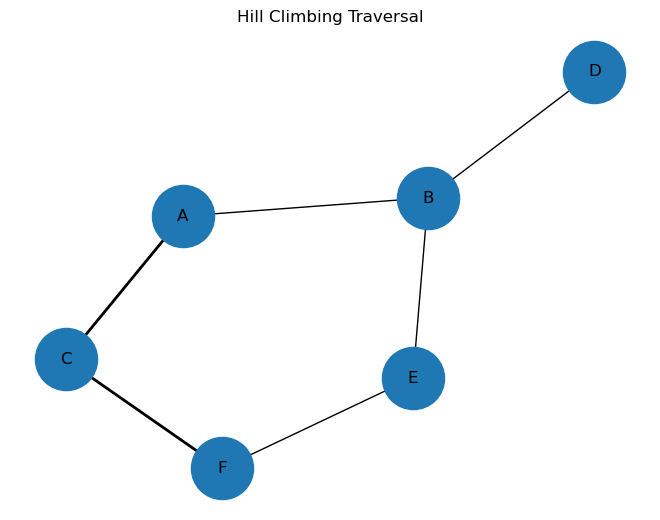

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

print("Implement Hill Climbing traversal for the given graph starting from node 'A'.")

# Graph
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['F'],
    'F': []
}

heuristic = {
    'A': 6,
    'B': 4,
    'C': 2,
    'D': 3,
    'E': 1,
    'F': 0
}

def hill_climbing(graph, start):
    current = start
    visited = [current]

    while True:
        neighbors = graph[current]

        if not neighbors:
            break

        next_node = min(neighbors,
                        key=lambda node: heuristic[node])

        if heuristic[next_node] >= heuristic[current]:
            break

        current = next_node
        visited.append(current)

    return visited

result = hill_climbing(graph, 'A')

arrow_path = " -> ".join(result)

print("\nHill Climbing Traversal (List):", result)
print("Hill Climbing Traversal (Path):", arrow_path)

print("\n", pd.DataFrame(result, columns=["Traversal"]))

G = nx.Graph([(u, v) for u in graph for v in graph[u]])
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000)

nx.draw_networkx_edges(
    G, pos,
    edgelist=[(result[i], result[i+1])
              for i in range(len(result)-1)],
    width=2
)

plt.title("Hill Climbing Traversal")
plt.show()